#

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create sample dataset
data = {
    'Student ID': [1, 2, 3, 4, 5],
    'Age': [18, 20, np.nan, 19, 22],
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male'],
    'Exam Score': [90, 85, 75, 95, 65],
    'Study Hours': [4, 6, 8, np.nan, 5],
    'Attendance Percentage': [80, 95, 85, 70, 60]
}
df = pd.DataFrame(data)

# print dataset
df

,Student ID,Age,Gender,Exam Score,Study Hours,Attendance Percentage
0,1,18.0,Male,90,4.0,80
1,2,20.0,Female,85,6.0,95
2,3,NaN,Female,75,8.0,85
3,4,19.0,Male,95,NaN,70
4,5,22.0,Male,65,5.0,60


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student ID             5 non-null      int64  
 1   Age                    4 non-null      float64
 2   Gender                 5 non-null      str    
 3   Exam Score             5 non-null      int64  
 4   Study Hours            4 non-null      float64
 5   Attendance Percentage  5 non-null      int64  
dtypes: float64(2), int64(3), str(1)
memory usage: 372.0 bytes


In [3]:
df.describe()

,Student ID,Age,Exam Score,Study Hours,Attendance Percentage
count,5.000000,4.000000,5.000000,4.000000,5.000000
mean,3.000000,19.750000,82.000000,5.750000,78.000000
std,1.581139,1.707825,12.041595,1.707825,13.509256
min,1.000000,18.000000,65.000000,4.000000,60.000000
25%,2.000000,18.750000,75.000000,4.750000,70.000000
50%,3.000000,19.500000,85.000000,5.500000,80.000000
75%,4.000000,20.500000,90.000000,6.500000,85.000000
max,5.000000,22.000000,95.000000,8.000000,95.000000


In [4]:
df.isnull()

,Student ID,Age,Gender,Exam Score,Study Hours,Attendance Percentage
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,True,False,False,False,False
3,False,False,False,False,True,False
4,False,False,False,False,False,False


In [5]:
# Handle missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Study Hours'].fillna(df['Study Hours'].mean(), inplace=True)

C:\Users\prath\AppData\Local\Temp\ipykernel_79356\2693269043.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\prath\AppData\Local\Temp\ipykernel_79356\2693269043.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment

0    4.00
1    6.00
2    8.00
3    5.75
4    5.00
Name: Study Hours, dtype: float64

In [6]:
# Now everything is okay
df.isnull().sum()

Student ID               0
Age                      1
Gender                   0
Exam Score               0
Study Hours              1
Attendance Percentage    0
dtype: int64

In [7]:
# Check for inconsistencies
# no of time a value is given in dataset
print(df['Age'].value_counts())

Age
18.0    1
20.0    1
19.0    1
22.0    1
Name: count, dtype: int64


In [8]:
# Detect outliers using IQR method
# Handle outliers by replacing with maximum and minimum values
lower_bound = 65
upper_bound = 95

df['Exam Score'] = np.where(df['Exam Score'] < lower_bound, lower_bound, df['Exam Score'])
df['Exam Score'] = np.where(df['Exam Score'] > upper_bound, upper_bound, df['Exam Score'])
df['Exam Score']

0    90
1    85
2    75
3    95
4    65
Name: Exam Score, dtype: int64

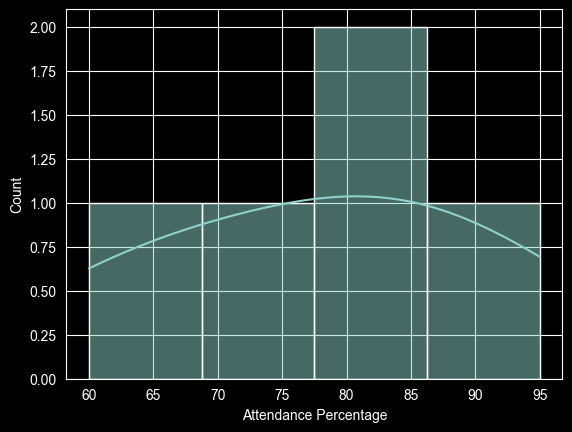

In [9]:
# Check the distribution of 'Attendance Percentage' variable
sns.histplot(df['Attendance Percentage'], kde=True)
plt.show()

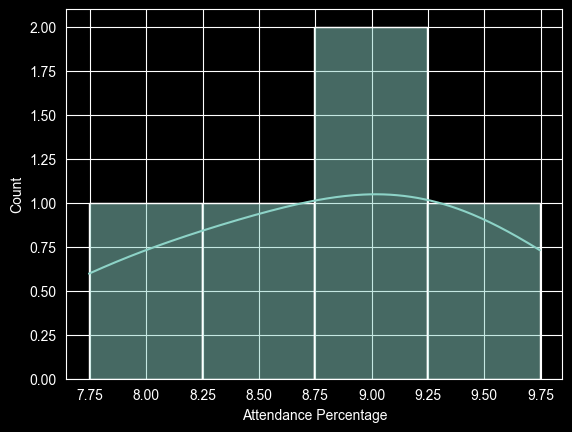

In [10]:
# Apply square root transformation
df['Attendance Percentage'] = np.sqrt(df['Attendance Percentage'])

# Check the transformed distribution
sns.histplot(df['Attendance Percentage'], kde=True)
plt.show()